In [ ]:
# Step 1: Load and Understand the Data
# ------------------------------------------------------------
# Gather and analyze the dataset to understand its structure,
# content, and key attributes.

In [3]:
import pandas as pd
df = pd.read_csv('student_access_dataset.csv')

print('Sample Rows')
print(df.head())

print("DataSet Shape")
print(f'Rows:{df.shape[0]}, Columns:{df.shape[1]}')

print('Dataset Info')
print(df.info())

print('Summary Statistics')
print(df.describe(include='all'))

print('Missing values')
print(df.isnull().sum())

Sample Rows
   StudyHours  Attendance  PastScore Internet  SleepHours Passed
0           2          60         40      Yes           5     No
1           5          80         60       No           6    Yes
2           8          90         75      Yes           8    Yes
3           3          70         50      Yes           5     No
4           7          85         70       No           7    Yes
DataSet Shape
Rows:20, Columns:6
Dataset Info
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   StudyHours  20 non-null     int64
 1   Attendance  20 non-null     int64
 2   PastScore   20 non-null     int64
 3   Internet    20 non-null     str  
 4   SleepHours  20 non-null     int64
 5   Passed      20 non-null     str  
dtypes: int64(4), str(2)
memory usage: 1.1 KB
None
Summary Statistics
        StudyHours  Attendance  PastScore Internet  SleepHours Passed
count    

In [ ]:
# Step 2: Pre-processing (Clean Data)
# ------------------------------------------------------------
# Handle missing values, outliers, and inconsistencies
# to ensure data quality and reliability.

In [9]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('student_access_dataset.csv')
print("Missing values in each column")
print(df.isnull().sum())

le = LabelEncoder()
df['Internet']=le.fit_transform(df['Internet'])
df['Passed'] = le.fit_transform(df['Passed'])

print('After Encoding')
print(df.head())

print('Data-types after cleaning')
print(df.dtypes)

Missing values in each column
StudyHours    0
Attendance    0
PastScore     0
Internet      0
SleepHours    0
Passed        0
dtype: int64
After Encoding
   StudyHours  Attendance  PastScore  Internet  SleepHours  Passed
0           2          60         40         1           5       0
1           5          80         60         0           6       1
2           8          90         75         1           8       1
3           3          70         50         1           5       0
4           7          85         70         0           7       1
Data-types after cleaning
StudyHours    int64
Attendance    int64
PastScore     int64
Internet      int64
SleepHours    int64
Passed        int64
dtype: object


In [10]:
# Step 3: Feature Scaling (If Needed)
# ------------------------------------------------------------
# Normalize or standardize features to improve
# model performance and consistency.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df.drop('Passed',axis=1))
print('Scaled Features Shape',scaled_features.shape)


Scaled Features Shape (20, 5)


In [11]:
# Step 4: Split the data
# ------------------------------------------------------------
# Devide the dataset into training,
# validation and test sets
from sklearn.model_selection import train_test_split

X = scaled_features
y = df['Passed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Set Size:", X_train.shape)
print("Test Set Size:", X_test.shape)

Training Set Size: (16, 5)
Test Set Size: (4, 5)


In [13]:
# Step 5: Train a Model
# ------------------------------------------------------------
# Select and train a machine learning model on the training data
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
print("Model Training Complete")

Model Training Complete


In [14]:
# Step 6: Make Predictions
# ------------------------------------------------------------
# Use the trained model to generate prediction on new data
y_pred = model.predict(X_test)
print("Predictions:", y_pred[:10])

Predictions: [0 1 1 0]


In [15]:
# Step 7: Evaluate the model
# ------------------------------------------------------------
# Access the model performace using appropriate metrics
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.75
Classification Report:
               precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       1.00      0.67      0.80         3

    accuracy                           0.75         4
   macro avg       0.75      0.83      0.73         4
weighted avg       0.88      0.75      0.77         4



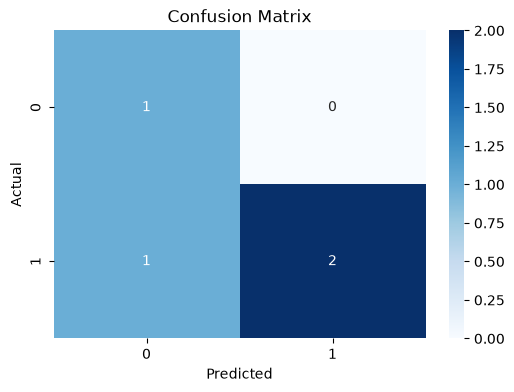

In [16]:
# Step 8: Visualize Results
# ------------------------------------------------------------
# Create visualizations to communicate findings and insights
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Step 9: Improve / Experiment (Optional)
# --------------------------------------------------------------------
# Refine the model through hyperparameter tuning or feature engineerng

In [17]:
# Step 10: Warp-Up
# --------------------------------------------------------------------
# Summarize the project and document key findings
print("✅ Workflow Complete: Data loaded, cleaned, scaled, model trained, evaluated, and visualized.")

✅ Workflow Complete: Data loaded, cleaned, scaled, model trained, evaluated, and visualized.
